In [1]:
# %% [markdown]
# # Avaliação de Papers — Estado da Arte
# 
# **Sumário**
# 1. Setup & Config
# 2. Carregamento & Deduplicação
# 3. Keywords: limpeza, universo e contagens
# 4. Embeddings & Clustering de Keywords (HDBSCAN)
# 5. Rotulagem de Tópicos por Paper
# 6. Séries temporais (tópicos por ano)
# 7. Visualizações (barras, heatmap de coocorrência)
# 8. Autores & Rede de Coautoria
# 9. Similaridade entre Papers (por keywords)
# 10. Interseção de keywords (contagem) & métricas
# 11. Export de artefatos (CSV/GEXF/figuras)

from datetime import datetime
print("Last run:", datetime.now().isoformat(timespec="seconds"))


Last run: 2025-09-22T05:10:36


In [2]:
# %% [markdown]
# ## 1) Setup & Config
import pickle
from dataclasses import asdict
import os, re, unicodedata, itertools, math
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Modelos e clustering (ligados à parte de embeddings)
from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import normalize
import hdbscan

# Similaridade / PCA
from sklearn.metrics import pairwise_distances
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA

# Graph (coautoria e tópicos)
import networkx as nx
from networkx.algorithms.community import greedy_modularity_communities

plt.rcParams["figure.dpi"] = 120

# Pastas
DIR_PAPERS = "papers"
DIR_OUT    = "outputs"
os.makedirs(DIR_OUT, exist_ok=True)

# Mapeamento amigável de clusters (ajuste conforme seu dicionário)
cluster_names = {
    -1:  "Ruído",
    0:   "Dependência & Correlação",
    1:   "Cenários de Uso",
    2:   "Fluxo de Controle & Grafos",
    3:   "Diagramas de Classe & Estrutura",
    4:   "Avaliação & Assessment",
    5:   "Recuperação & Extração de Informação",
    6:   "Análise de Tarefas",
    7:   "Teste & Depuração de Software",
    8:   "Tradução Automática / Machine Translation",
    9:   "Sistemas Industriais & Ciberfísicos",
    10:  "Frameworks & Modelagem OO",
    11:  "Semântica & Similaridade",
    12:  "Engenharia Reversa",
    13:  "Visualização & Ferramentas Visuais",
    14:  "IA & Aprendizado de Máquina",
    15:  "Manutenção de Software",
    16:  "Processamento de Linguagem Natural (NLP)",
    17:  "Grandes Modelos de Linguagem (LLMs)",
    18:  "Modelagem & Sistemas de Modelos",
    19:  "UML",
    20:  "Engenharia de Software (Geral)",
    21:  "Educação em Computação",
    22:  "Sumarização & Representação de Código",
    23:  "Java & Linguagens"
}


/home/kenai/projects/vscode/lisa-llm-reqs/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# %% [markdown]
# ## 2) Carregamento & Deduplicação
# Ajuste estas funções para usar seus helpers `extract_researches_results` e `extract_papers`.

from pathlib import Path

def extract_researches_results(rot_dir: str | os.PathLike): 
    researches = []
    for papers in os.listdir(rot_dir):
        researches_results_path = os.path.join(rot_dir, papers)
        with open(researches_results_path, "rb") as file: 
            research = asdict(pickle.load(file))
            researches.append(research)
    return researches

def extract_papers(researches : list[dict]):            
    papers = []
    for results in researches:
        for paper in results["papers"].values():
            papers.append(paper)
    return papers
dir_acm_path = os.path.join("papers", "acm")
dir_ieee_path = os.path.join("papers", "ieee")
    
researches_acm = extract_papers(extract_researches_results(dir_acm_path))
researches_ieee = extract_papers(extract_researches_results(dir_ieee_path))

researches = researches_acm
researches.extend(researches_ieee)


df = pd.DataFrame(researches)

# dedupe por DOI (fallback por título se necessário)
if "DOI" in df.columns and df["DOI"].notna().any():
    df_clean = df.drop_duplicates(subset="DOI", keep="first").reset_index(drop=True)
else:
    df_clean = df.drop_duplicates(subset="title", keep="first").reset_index(drop=True)

# garante coluna year (tenta extrair de 'date' se houver)
def parse_year(x):
    if pd.isna(x): return np.nan
    s = str(x)
    m = re.search(r"(19|20)\d{2}", s)
    return int(m.group(0)) if m else np.nan

if "year" not in df_clean.columns:
    df_clean["year"] = df_clean["date"].apply(parse_year) if "date" in df_clean.columns else np.nan

df_clean["year"] = df_clean["year"].astype("Int64")
print("Papers:", len(df_clean), "| Com ano:", df_clean["year"].notna().sum())


Papers: 37 | Com ano: 37


In [4]:
df_clean.columns

Index(['title', 'date', 'abstract', 'DOI', 'source_url', 'authors', 'keywords',
       'year'],
      dtype='object')

In [5]:
# %% [markdown]
# ## 3) Keywords: limpeza, universo e contagens

def _norm_token(s: str) -> str:
    if not isinstance(s, str): return ""
    tbl = str.maketrans("", "", r"""!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~""")
    s = unicodedata.normalize("NFKC", s).lower().strip().translate(tbl)
    s = re.sub(r"\s+", " ", s)
    return s

def clean_kw_list(lst):
    if not isinstance(lst, (list, tuple, set)): return []
    out = []
    for k in lst:
        if isinstance(k, str):
            k2 = _norm_token(k)
            if k2:
                out.append(k2)
    return sorted(set(out))

# normaliza keywords
df_clean["keywords"] = df_clean["keywords"].apply(clean_kw_list)
#print(df_clean["keywords"])
#print(type(df_clean["keywords"]))
#print(df_clean["keywords"].iloc(0))
#print(type(df_clean["keywords"].iloc(0)))
# universo e contagens
valid_keywords = [k for ks in df_clean["keywords"] for k in ks]
kw_counts = Counter(valid_keywords)
df_kw = pd.DataFrame(list(kw_counts.items()), columns=["keyword","count"]).sort_values("count", ascending=False).reset_index(drop=True)
print("Keywords únicas:", len(df_kw))
df_kw.head(10)


Keywords únicas: 519


,keyword,count
0,source code,13
1,software and its engineering,12
2,software creation and management,9
3,reverse engineering,8
4,natural language,8
5,software maintenance,8
6,software notations and tools,8
7,visualization,7
8,software development,7
9,information retrieval,7


In [6]:
# %% [markdown]
# ## 4) Embeddings & Clustering de Keywords (HDBSCAN)

# Modelo pré-treinado
model = SentenceTransformer("all-MiniLM-L6-v2")

# Monta o texto combinado: keywords + abstract
def build_text(row):
    kws = ", ".join(row["keywords"]) if isinstance(row["keywords"], list) else ""
    abstract = row.get("abstract", "")
    return f"Keywords: {kws}. Abstract: {abstract}"

df_clean["text_emb"] = df_clean.apply(build_text, axis=1)

# Gera embeddings
X_abs_kw = model.encode(df_clean["text_emb"], show_progress_bar=True)

# Normaliza para usar em métricas (opcional)
X_abs_kw_n = normalize(X_abs_kw)

clusterer = hdbscan.HDBSCAN(min_cluster_size=3, metric="euclidean")
df_kw["cluster"] = clusterer.fit_predict(X_abs_kw_n)

# dicionário cluster -> lista de keywords
clusters = (df_kw.groupby("cluster")["keyword"].apply(list).to_dict())

# (opcional) inspecionar quickly
for cid, terms in list(clusters.items())[:6]:
    print(cid, ":", terms[:8], "...")


Batches: 100%|██████████| 2/2 [00:00<00:00,  5.55it/s]
/home/kenai/projects/vscode/lisa-llm-reqs/.venv/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/kenai/projects/vscode/lisa-llm-reqs/.venv/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


ValueError: Length of values (37) does not match length of index (519)

In [ ]:
# %% [markdown]
# ## 5) Rotulagem de Tópicos por Paper

def _to_token_set(words):
    if not isinstance(words, (list, tuple, set)): return set()
    return {_norm_token(w) for w in words if isinstance(w, str) and _norm_token(w)}

def label_topics(keywords, clusters_dict):
    keyset = _to_token_set(keywords)
    hits = []
    for cid, terms in clusters_dict.items():
        termset = _to_token_set(terms)
        if keyset & termset:
            hits.append(cid)
    return hits or ["Other"]

df_clean["topic_ids"] = df_clean["keywords"].apply(lambda ks: label_topics(ks, clusters))
df_clean["topic_names"] = df_clean["topic_ids"].apply(lambda ids: [cluster_names.get(i, f"Cluster {i}") for i in ids])
df_clean[["title","year","topic_ids","topic_names"]].head(6)


,title,year,topic_ids,topic_names
0,Supporting Readability by Comprehending the Hi...,2022,"[-1, 1, 2]","[Ruído, Cenários de Uso, Fluxo de Controle & G..."
1,Test2Feature: feature-based test traceability ...,2022,"[-1, 1]","[Ruído, Cenários de Uso]"
2,Executable Multi-Layered Software Models,2024,[1],[Cenários de Uso]
3,Re-Engineering Microservices into Web-Based So...,2025,"[-1, 1]","[Ruído, Cenários de Uso]"
4,Enhancing Model-Driven Reverse Engineering Usi...,2024,[Other],[Cluster Other]
5,An Empirical Study of Code Simplification Meth...,2025,"[-1, 1]","[Ruído, Cenários de Uso]"


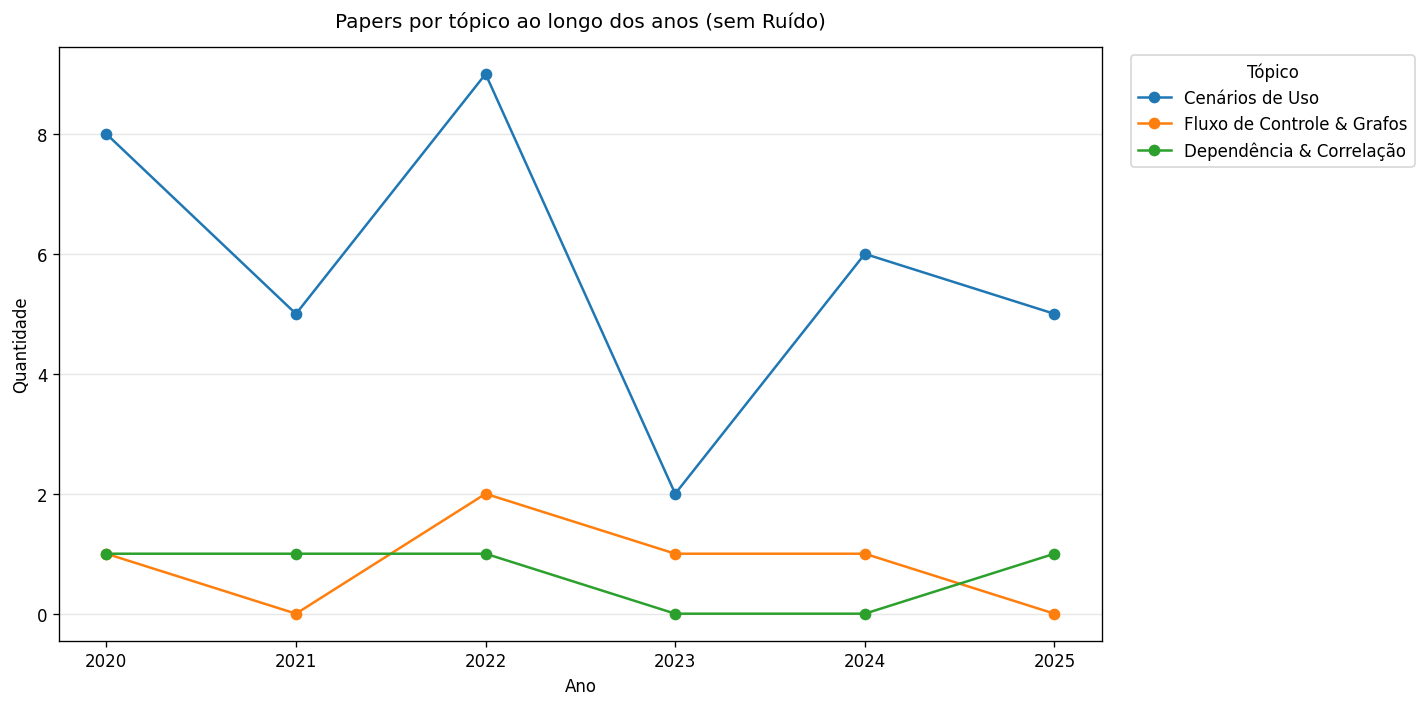

In [ ]:
# %% [markdown]
# ## 6) Séries temporais — Tópicos por ano (linhas)

tp = df_clean.explode("topic_ids", ignore_index=True)
tp = tp[(tp["topic_ids"] != "Other") & (tp["topic_ids"] != -1)]
tp = tp[tp["year"].notna()].copy()
tp["year"] = tp["year"].astype(int)
tp["topic_name"] = tp["topic_ids"].map(cluster_names)

counts = (tp.groupby(["year","topic_name"]).size()
            .rename("n").reset_index()
            .pivot(index="year", columns="topic_name", values="n")
            .fillna(0).sort_index())

TOP_K = 8
if TOP_K:
    top_topics = counts.sum().sort_values(ascending=False).head(TOP_K).index
    counts = counts[top_topics]

plt.figure(figsize=(12,6))
ax = counts.plot(ax=plt.gca(), marker="o")
ax.set_title("Papers por tópico ao longo dos anos (sem Ruído)", pad=12)
ax.set_xlabel("Ano"); ax.set_ylabel("Quantidade")
ax.grid(True, axis="y", alpha=0.3)
ax.legend(title="Tópico", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout(); plt.show()


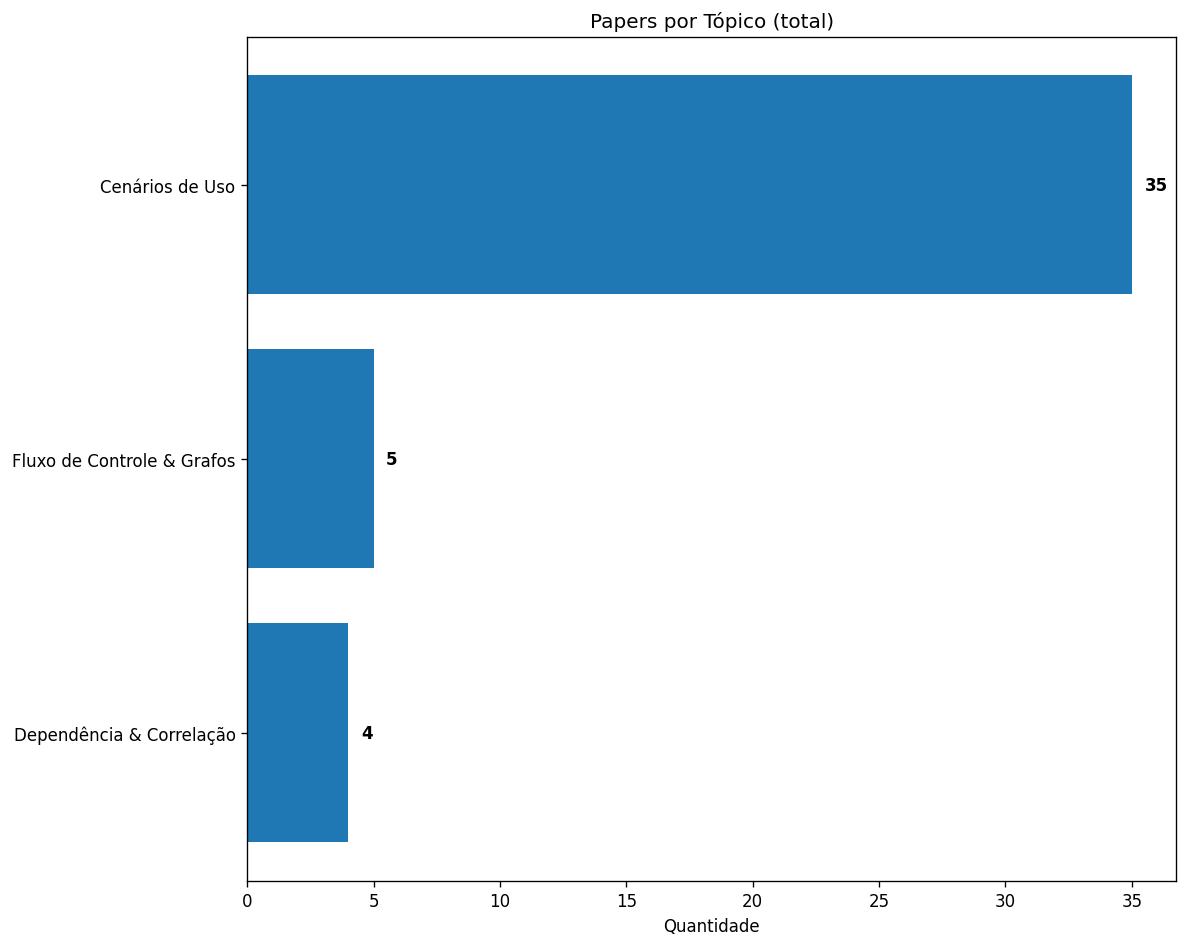

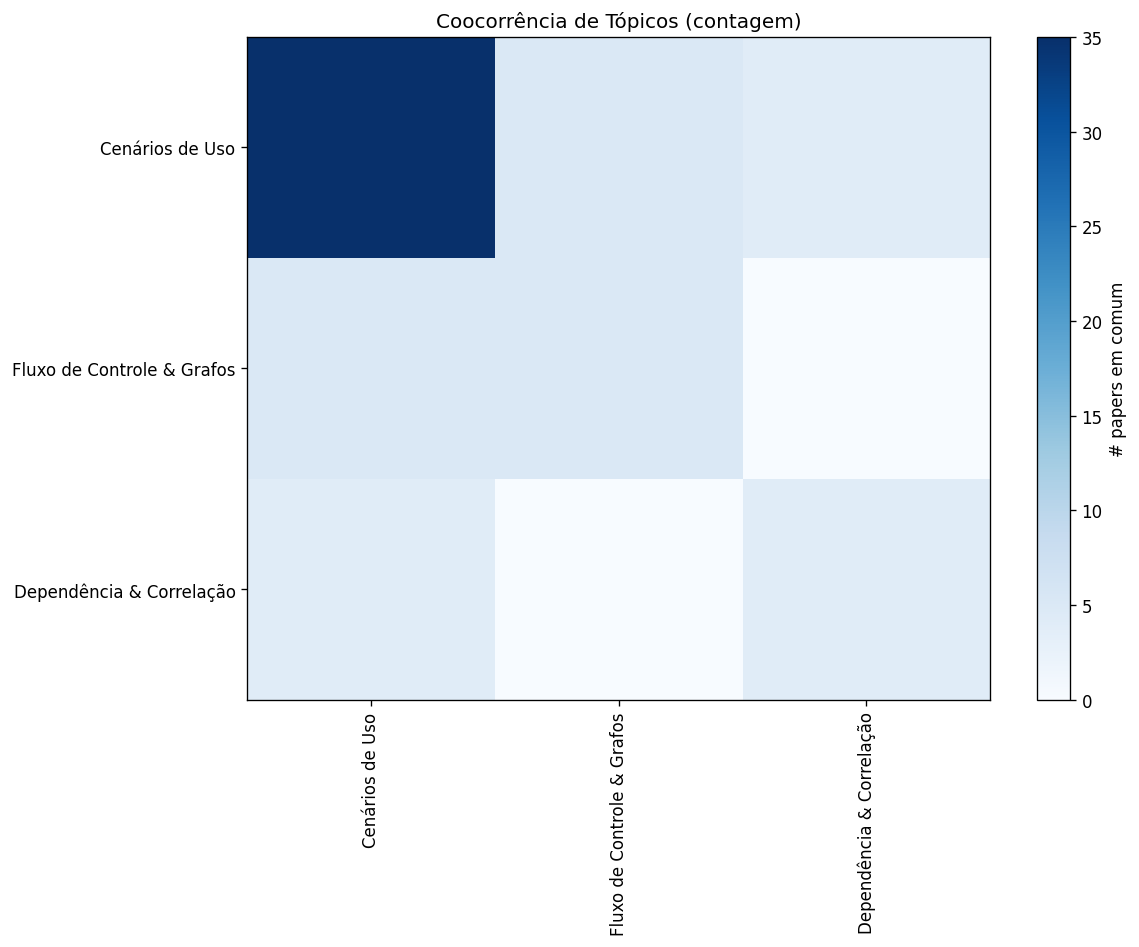

In [ ]:
# %% [markdown]
# ## 7) Barras & Heatmap de coocorrência

# Barras horizontais — contagem total por tópico
tp_bar = df_clean.explode("topic_ids", ignore_index=True)
tp_bar = tp_bar[(tp_bar["topic_ids"] != "Other") & (tp_bar["topic_ids"] != -1)]
counts_bar = (tp_bar.groupby("topic_ids").size().rename("n").reset_index())
counts_bar["topic_name"] = counts_bar["topic_ids"].map(cluster_names)
counts_bar = counts_bar.sort_values("n")

plt.figure(figsize=(10,8)); ax = plt.gca()
bars = ax.barh(counts_bar["topic_name"], counts_bar["n"])
plt.title("Papers por Tópico (total)")
plt.xlabel("Quantidade")

# anota valores no fim
for b in bars:
    w = b.get_width()
    ax.text(w + 0.5, b.get_y() + b.get_height()/2, f"{w:.0f}", va="center", ha="left", fontweight="bold")

plt.tight_layout(); plt.show()

# Heatmap de coocorrência (contagem bruta) dos TOP_K tópicos
from itertools import combinations

topic_sets = (df_clean["topic_ids"]
              .apply(lambda xs: sorted({t for t in xs if t != "Other" and t != -1})))

topic_support = pd.Series([t for ts in topic_sets for t in ts]).value_counts()
TOP_K = 20
topics = topic_support.head(TOP_K).index.tolist()

idx = {t:i for i,t in enumerate(topics)}
cooc = np.zeros((len(topics), len(topics)), dtype=int)

for ts in topic_sets:
    ts = [t for t in ts if t in idx]
    for t in ts: cooc[idx[t], idx[t]] += 1
    for a,b in combinations(ts, 2):
        i,j = idx[a], idx[b]
        cooc[i,j]+=1; cooc[j,i]+=1

labels = [cluster_names.get(t, f"Cluster {t}") for t in topics]
plt.figure(figsize=(10,8))
im = plt.imshow(cooc, aspect="auto", cmap="Blues")
plt.colorbar(im, label="# papers em comum")
plt.xticks(range(len(labels)), labels, rotation=90)
plt.yticks(range(len(labels)), labels)
plt.title("Coocorrência de Tópicos (contagem)")
plt.tight_layout(); plt.show()


,authors,n_papers
35,Hanan Abdulwahab Siala,2
94,Wei Liu,2
91,Tingting Xu,2
84,Shanping Li,2
70,Meng Yan,2
121,Zhongxin Liu,2
107,Xin Xia,2
5,Ally S. Nyamawe,1
6,Andrea De Lucia,1
1,A. Karlis,1


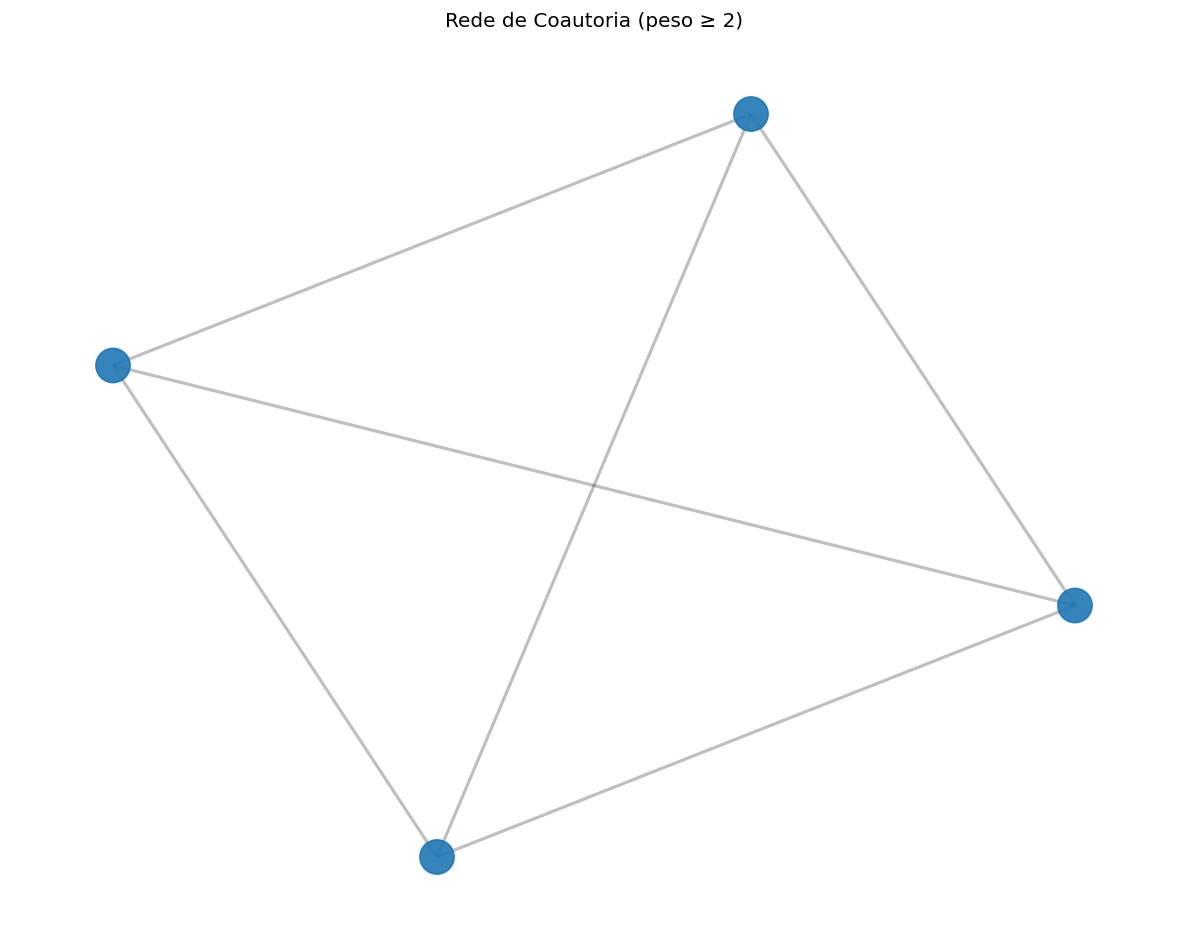

In [ ]:
# %% [markdown]
# ## 8) Autores & Rede de Coautoria

# Top autores
au = df_clean.explode("authors", ignore_index=True)
au = au[au["authors"].notna() & au["authors"].astype(str).str.strip().ne("")]
top_authors = (au.groupby("authors").size().rename("n_papers")
                 .reset_index().sort_values("n_papers", ascending=False))
display(top_authors.head(20))

# Rede (arestas por coautoria)
edges = []
for authors in (df_clean["authors"].apply(lambda xs: sorted({a.strip() for a in xs if isinstance(a,str) and a.strip()}))):
    if len(authors) < 2: continue
    for u,v in itertools.combinations(authors,2):
        edges.append(tuple(sorted((u,v))))
edges_df = (pd.DataFrame(edges, columns=["u","v"]).value_counts()
            .rename("weight").reset_index())

G = nx.Graph()
for _, r in edges_df.iterrows():
    G.add_edge(r["u"], r["v"], weight=int(r["weight"]))

# comunidades
communities = list(greedy_modularity_communities(G))
comm_map = {a:cid for cid, comm in enumerate(communities) for a in comm}

# plot (filtra arestas com peso >= 2)
H = nx.Graph(((u,v,d) for u,v,d in G.edges(data=True) if d["weight"]>=2))
if H.number_of_edges()==0: H = G.copy()

pos = nx.spring_layout(H, seed=42, k=0.6)
node_sizes = [300 + 40*G.degree(n) for n in H.nodes()]
node_colors = [comm_map.get(n,-1) for n in H.nodes()]

plt.figure(figsize=(10,8))
nx.draw_networkx_edges(H, pos, alpha=0.25, width=[0.5+0.7*H[u][v]["weight"] for u,v in H.edges()])
nx.draw_networkx_nodes(H, pos, node_size=node_sizes, node_color=node_colors, cmap="tab20", alpha=0.9)
# rótulos top-20 por grau
deg = pd.Series(dict(G.degree())).sort_values(ascending=False)
to_label = set(deg.head(20).index) & set(H.nodes())
nx.draw_networkx_labels(H, pos, labels={n:n for n in to_label}, font_size=9)
plt.title("Rede de Coautoria (peso ≥ 2)"); plt.axis("off"); plt.tight_layout(); plt.show()


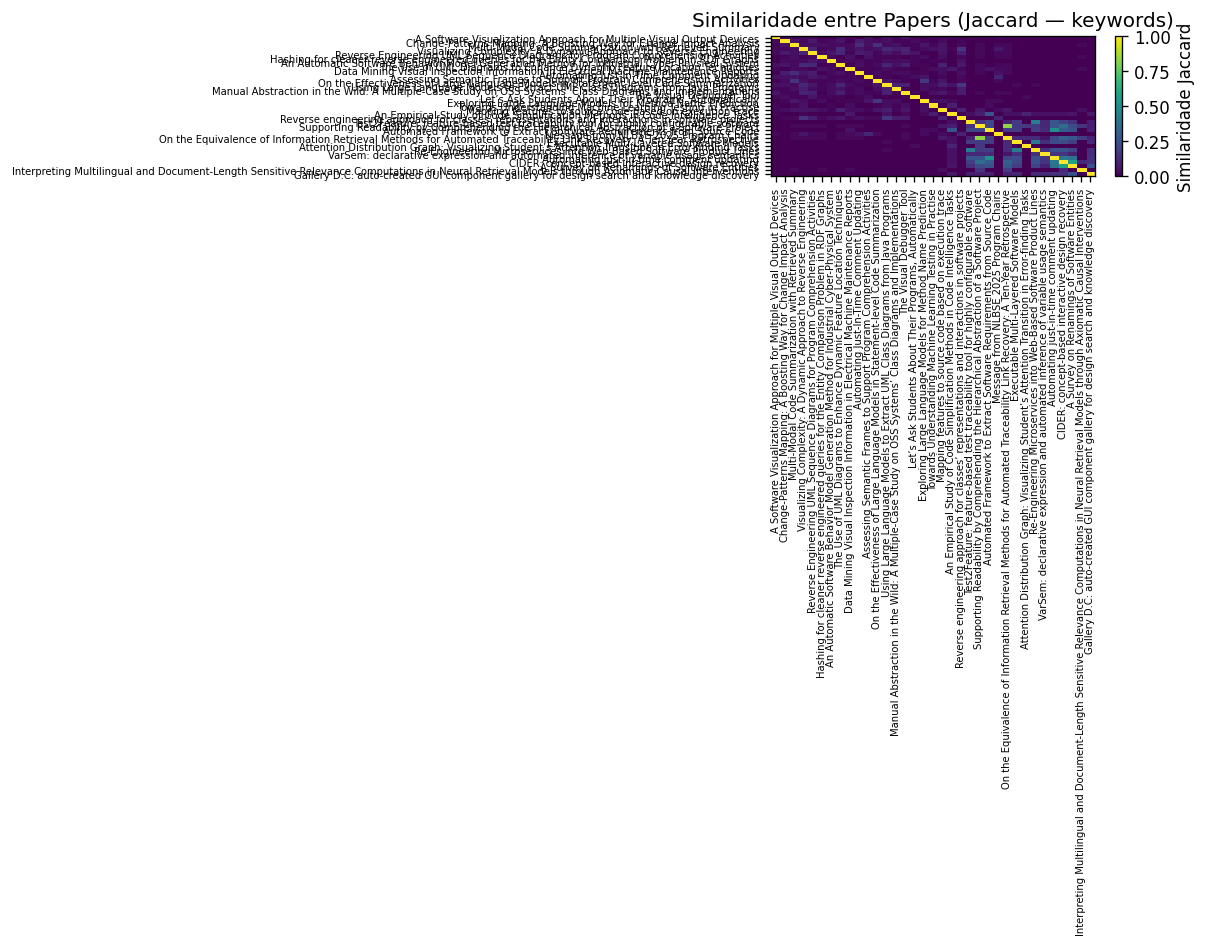

In [ ]:
# %% [markdown]
# ## 9) Similaridade entre Papers (por keywords)

tp_kw = df_clean[["title","keywords"]].explode("keywords")
tp_kw = tp_kw[tp_kw["keywords"].notna() & tp_kw["keywords"].astype(str).str.strip().ne("")]
paper_kw = pd.crosstab(tp_kw["title"], tp_kw["keywords"]).astype("uint8")

# Jaccard
X_bool = paper_kw.to_numpy(dtype=bool)
S_jacc = 1.0 - pairwise_distances(X_bool, metric="jaccard")
jacc_df = pd.DataFrame(S_jacc, index=paper_kw.index, columns=paper_kw.index)

# (opcional) heatmap de um subconjunto (top-40 por nº de keywords)
MAXP=40
sub = paper_kw.sum(axis=1).sort_values(ascending=False).head(MAXP).index
jacc_plot = jacc_df.loc[sub, sub]

plt.figure(figsize=(10,8))
im = plt.imshow(jacc_plot.values, cmap="viridis", vmin=0, vmax=1, aspect="auto")
plt.colorbar(im, label="Similaridade Jaccard")
plt.xticks(range(len(sub)), sub, rotation=90, fontsize=6)
plt.yticks(range(len(sub)), sub, fontsize=6)
plt.title("Similaridade entre Papers (Jaccard — keywords)")
plt.tight_layout(); plt.show()


In [ ]:
# %% [markdown]
# ## 10) Interseção de keywords (contagem) & métricas

# matriz de interseção (contagem) via produto matricial
M = paper_kw.to_numpy(dtype=np.uint16)
common = M @ M.T
common_df = pd.DataFrame(common, index=paper_kw.index, columns=paper_kw.index)

# média global sem diagonal
n = common_df.shape[0]
vals = common_df.to_numpy()
mean_global = vals[np.triu_indices(n, k=1)].mean() if n>1 else float("nan")
print(f"Média global de keywords em comum (pares i≠j): {mean_global:.3f}")

# top pares
pairs = []
idx = list(common_df.index)
for i in range(len(idx)):
    for j in range(i+1,len(idx)):
        c = int(common_df.iat[i,j])
        if c>0: pairs.append((idx[i], idx[j], c))
top_pairs = sorted(pairs, key=lambda x: -x[2])[:20]
for a,b,c in top_pairs:
    print(f"{c:3d} — {a}  ↔  {b}")


Média global de keywords em comum (pares i≠j): 1.071
 10 — On the Equivalence of Information Retrieval Methods for Automated Traceability Link Recovery: A Ten-Year Retrospective  ↔  Supporting Readability by Comprehending the Hierarchical Abstraction of a Software Project
  9 — Multi-Modal Code Summarization with Retrieved Summary  ↔  On the Effectiveness of Large Language Models in Statement-level Code Summarization
  8 — Automating Just-In-Time Comment Updating  ↔  Multi-Modal Code Summarization with Retrieved Summary
  8 — Exploring Large Language Models for Method Name Prediction  ↔  On the Effectiveness of Large Language Models in Statement-level Code Summarization
  8 — The Use of UML Diagrams to Enhance Dynamic Feature Location Techniques  ↔  Visualizing Complexity: A Dynamic Approach to Reverse Engineering
  7 — Reverse Engineering UML Sequence Diagrams for Program Comprehension Activities  ↔  The Use of UML Diagrams to Enhance Dynamic Feature Location Techniques
  7 — Reverse 

In [ ]:
# %% [markdown]
# ## 11) Export (opcional)

df_clean.to_csv(os.path.join(DIR_OUT, "papers_clean.csv"), index=False)
df_kw.to_csv(os.path.join(DIR_OUT, "keywords_clustered.csv"), index=False)
top_authors.head(100).to_csv(os.path.join(DIR_OUT, "top_authors.csv"), index=False)
# Exporte grafos para o Gephi, se quiser:
# nx.write_gexf(G, os.path.join(DIR_OUT, "coauthorship.gexf"))
